■ Google drive **마운트**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


■ YOLO 학습을 위한 패키지 설치
- ultralytics 패키지
- opencv 패키지

In [3]:
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 35.6 MB/s eta 0:00:00


In [4]:
# @ 디버깅용
# 패키지가 정상적으로 설치되었는지 확인
import cv2
from ultralytics import YOLO
print("OpenCV version:", cv2.__version__)
print("Ultralytics 설치 완료!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
OpenCV version: 4.13.0
Ultralytics 설치 완료!


■ 학습 전, 데이터셋 파일 위치 확인

In [5]:
import os

# data.yam파일이 위치 확인
if os.path.exists('/content/drive/MyDrive/colab_backup/dataset/Data/data.yaml'):
    print("✅ 파일 존재!")
else:
    print("❌ 파일 없음. 경로 확인 필요")

✅ 파일 존재!


In [ ]:
# 현재 data.yaml 내용 보기
!cat /content/drive/MyDrive/colab_backup/dataset/Data/data.yaml


path: /content/drive/MyDrive/colab_backup/dataset/Data
train: /content/drive/MyDrive/colab_backup/dataset/Data/train
val: /content/drive/MyDrive/colab_backup/dataset/Data/validation
test: /content/drive/MyDrive/colab_backup/dataset/Data/test

nc: 8
names: ['Cap1', 'Cap2', 'Cap3', 'Cap4', 'MOSFET', 'Mov', 'Resistor', 'Transformer']


In [ ]:
# data.yaml 파일 내부 학습 파일 경로 수정
# 학습파일 -> train, validation, test
data_yaml_content = """
path: /content/drive/MyDrive/colab_backup/dataset/Data
train: /content/drive/MyDrive/colab_backup/dataset/Data/train
val: /content/drive/MyDrive/colab_backup/dataset/Data/validation
test: /content/drive/MyDrive/colab_backup/dataset/Data/test

nc: 8
names: ['Cap1', 'Cap2', 'Cap3', 'Cap4', 'MOSFET', 'Mov', 'Resistor', 'Transformer']
"""

# data.yaml 파일 저장
with open('/content/drive/MyDrive/colab_backup/dataset/Data/data.yaml', 'w') as f:
    f.write(data_yaml_content)

print("✅ data.yaml 경로 수정 완료!")

# 수정된 내용 확인
print("\n 수정된 data.yaml 내용:")
!cat /content/drive/MyDrive/colab_backup/dataset/Data/data.yaml

✅ data.yaml 경로 수정 완료!

 수정된 data.yaml 내용:

path: /content/drive/MyDrive/colab_backup/dataset/Data
train: /content/drive/MyDrive/colab_backup/dataset/Data/train
val: /content/drive/MyDrive/colab_backup/dataset/Data/validation
test: /content/drive/MyDrive/colab_backup/dataset/Data/test

nc: 8
names: ['Cap1', 'Cap2', 'Cap3', 'Cap4', 'MOSFET', 'Mov', 'Resistor', 'Transformer']


■ 객체 학습시키기


***********밑에 있는 부분 코드화 하기 \
data.yaml 내부 작성 파일 내 경로 기록한거 확인하기!

-------------------------------------------------------------
클래스 'Resestor' 지우기 \

train: /content/dataset/Data/train \
val: /content/dataset/Data/validation \
test: /content/dataset/Data/test

In [ ]:
!yolo train data=/content/drive/MyDrive/colab_backup/dataset/Data/data.yaml \
           model=yolov8n.pt \
           epochs=50 \
           imgsz=640 \
           name=train_corrected \
           save_dir=/content/runs/detect/train_corrected


Ultralytics 8.4.13 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/colab_backup/dataset/Data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_corrected, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

■ 학습결과 검증하기 \

test파일과 비교한 결과들이 출력하게 됨

In [ ]:
# YOLOv8 예측 명령
!yolo detect predict \
    model=/content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/best.pt \
    source=/content/drive/MyDrive/colab_backup/dataset/Data/test/images \
    conf=0.25 \
    save=True


Ultralytics 8.4.13 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs

image 1/111 /content/drive/MyDrive/colab_backup/dataset/Data/test/images/VID20210601143927-96_jpg.rf.51037a593015ac38c8ac31613da3c066.jpg: 640x384 1 Cap1, 1 Cap2, 1 Cap3, 1 Cap4, 1 MOSFET, 1 Mov, 1 Resistor, 2 Transformers, 64.3ms
image 2/111 /content/drive/MyDrive/colab_backup/dataset/Data/test/images/VID20210601143927-96_jpg.rf.7ab5347b2d9efca349318d1c0f12a466.jpg: 640x384 1 Cap1, 1 Cap2, 1 Cap3, 1 Cap4, 1 MOSFET, 1 Mov, 1 Resistor, 2 Transformers, 13.4ms
image 3/111 /content/drive/MyDrive/colab_backup/dataset/Data/test/images/VID20210601143927-96_jpg.rf.f5f54e1ed4ec2434ed16cb072a95de94.jpg: 640x384 1 Cap1, 1 Cap2, 1 Cap3, 1 Cap4, 1 MOSFET, 1 Mov, 1 Resistor, 2 Transformers, 9.2ms
image 4/111 /content/drive/MyDrive/colab_backup/dataset/Data/test/images/VID20210601144014-45_jpg.rf.3f10bd61f03a52d57d80d50bffa68cb7.jpg: 640x38

■ 학습 검증결과 시각화하기

test/images 앞에서 5개만 시각화해서 보여주기

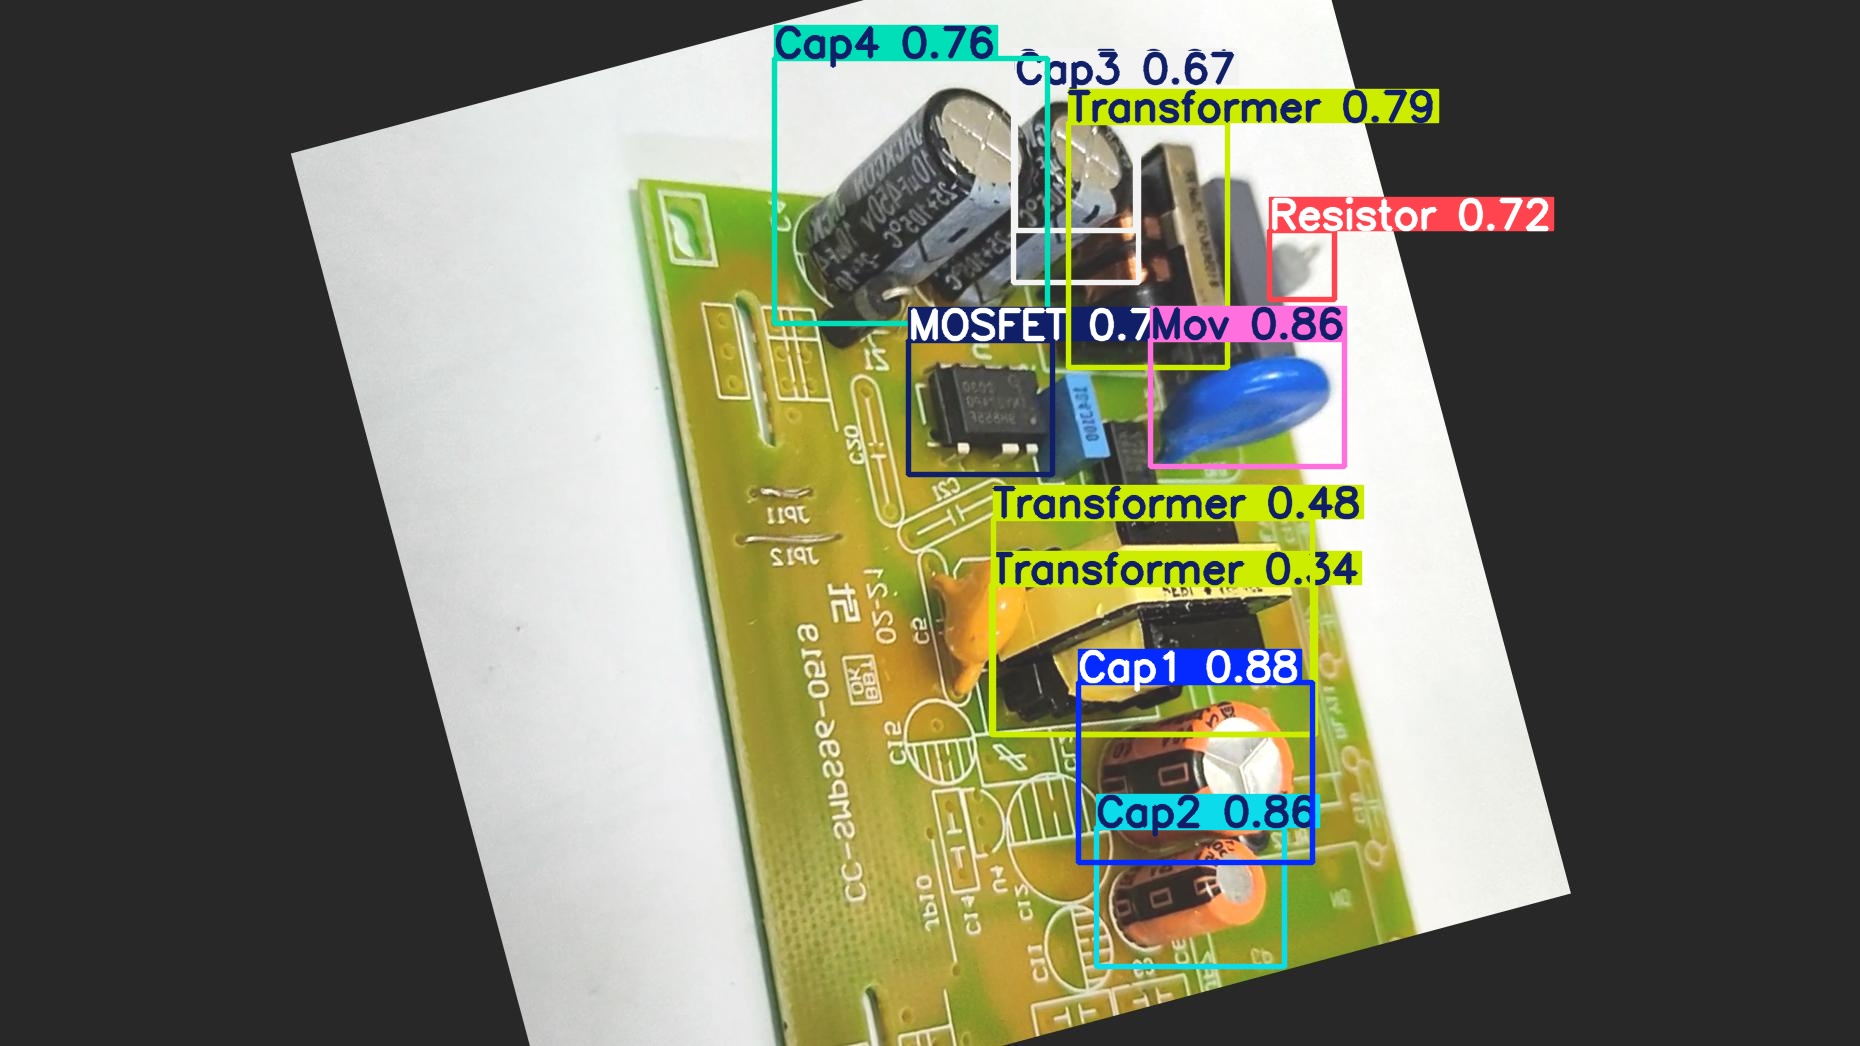

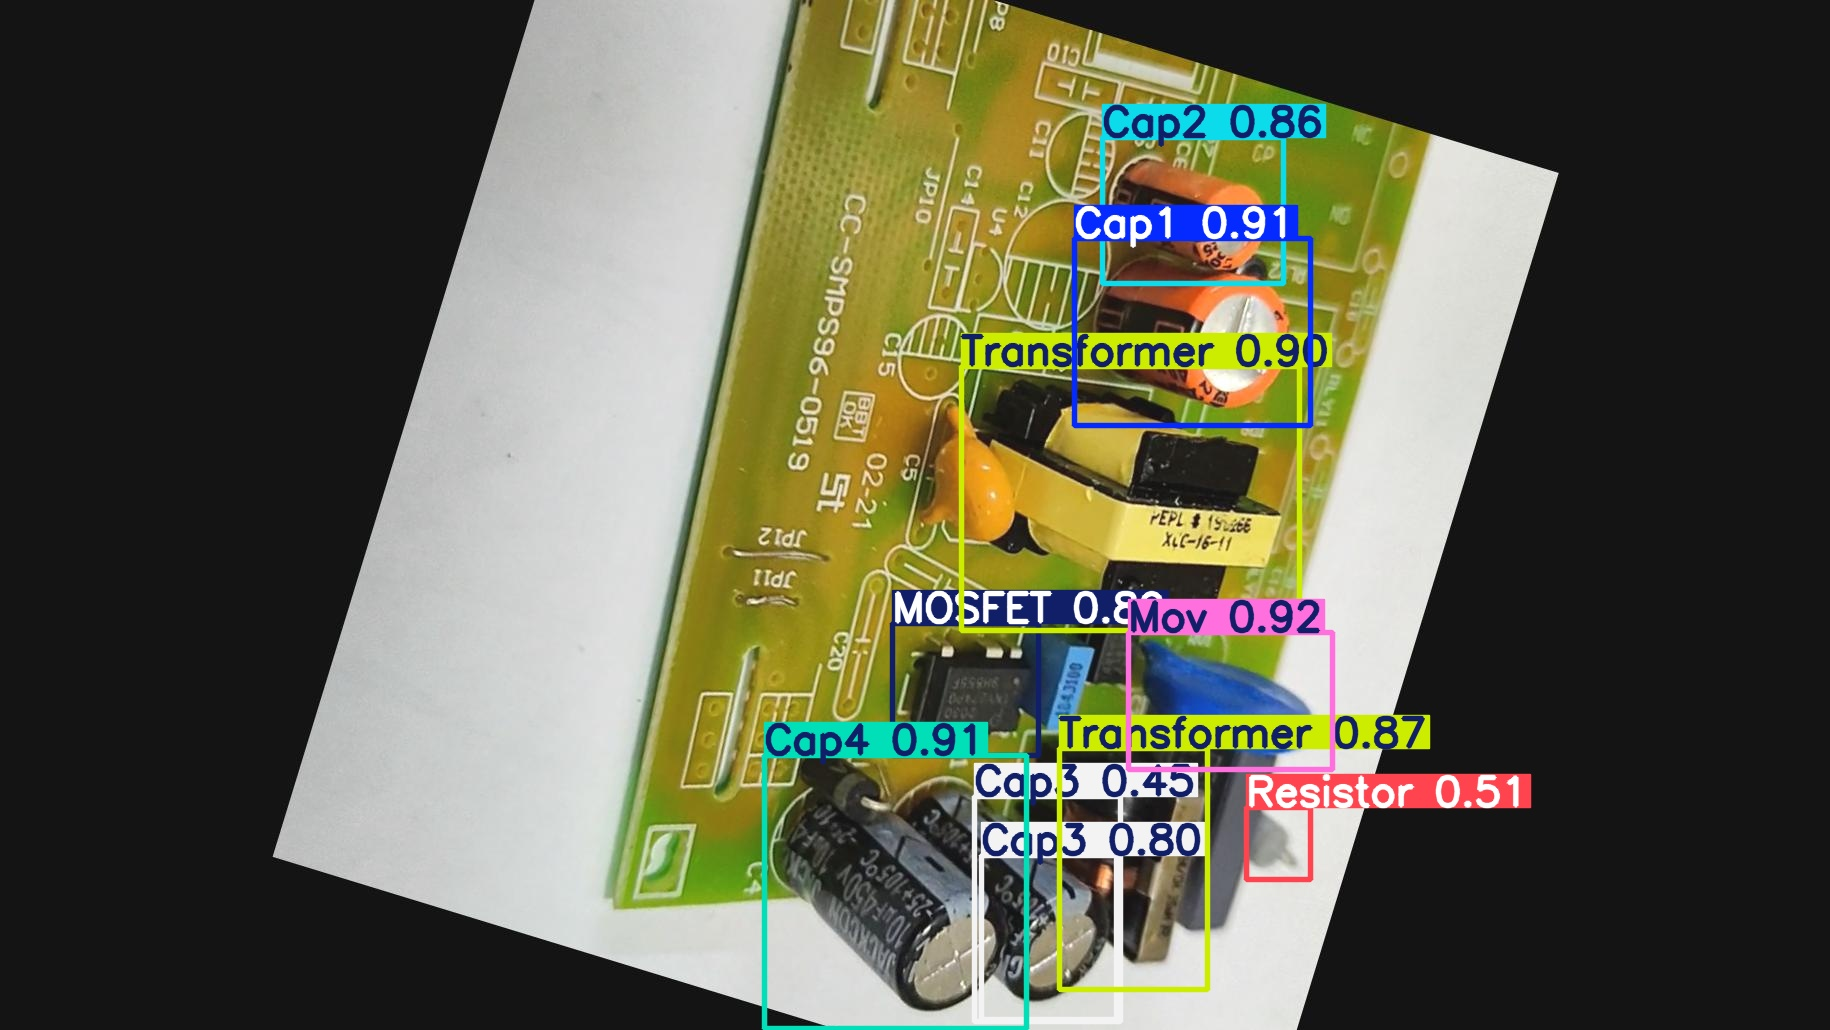

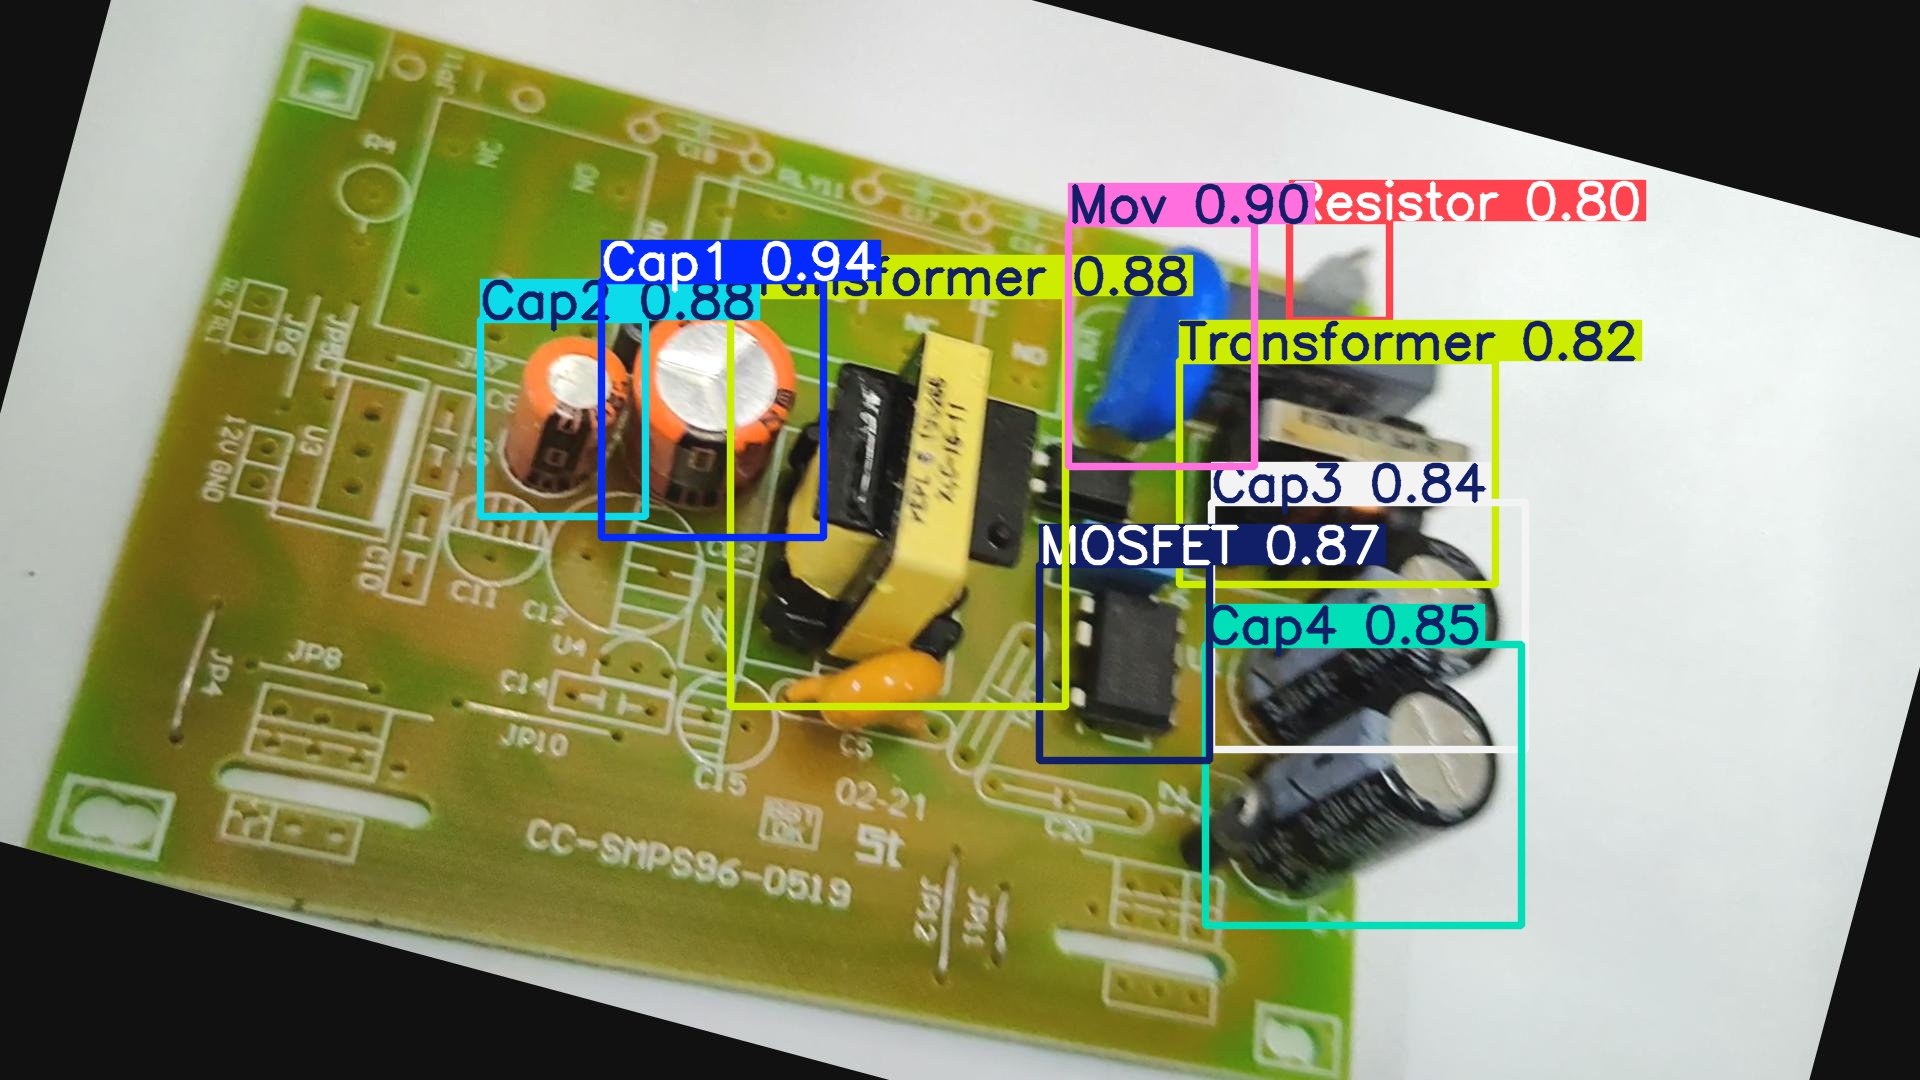

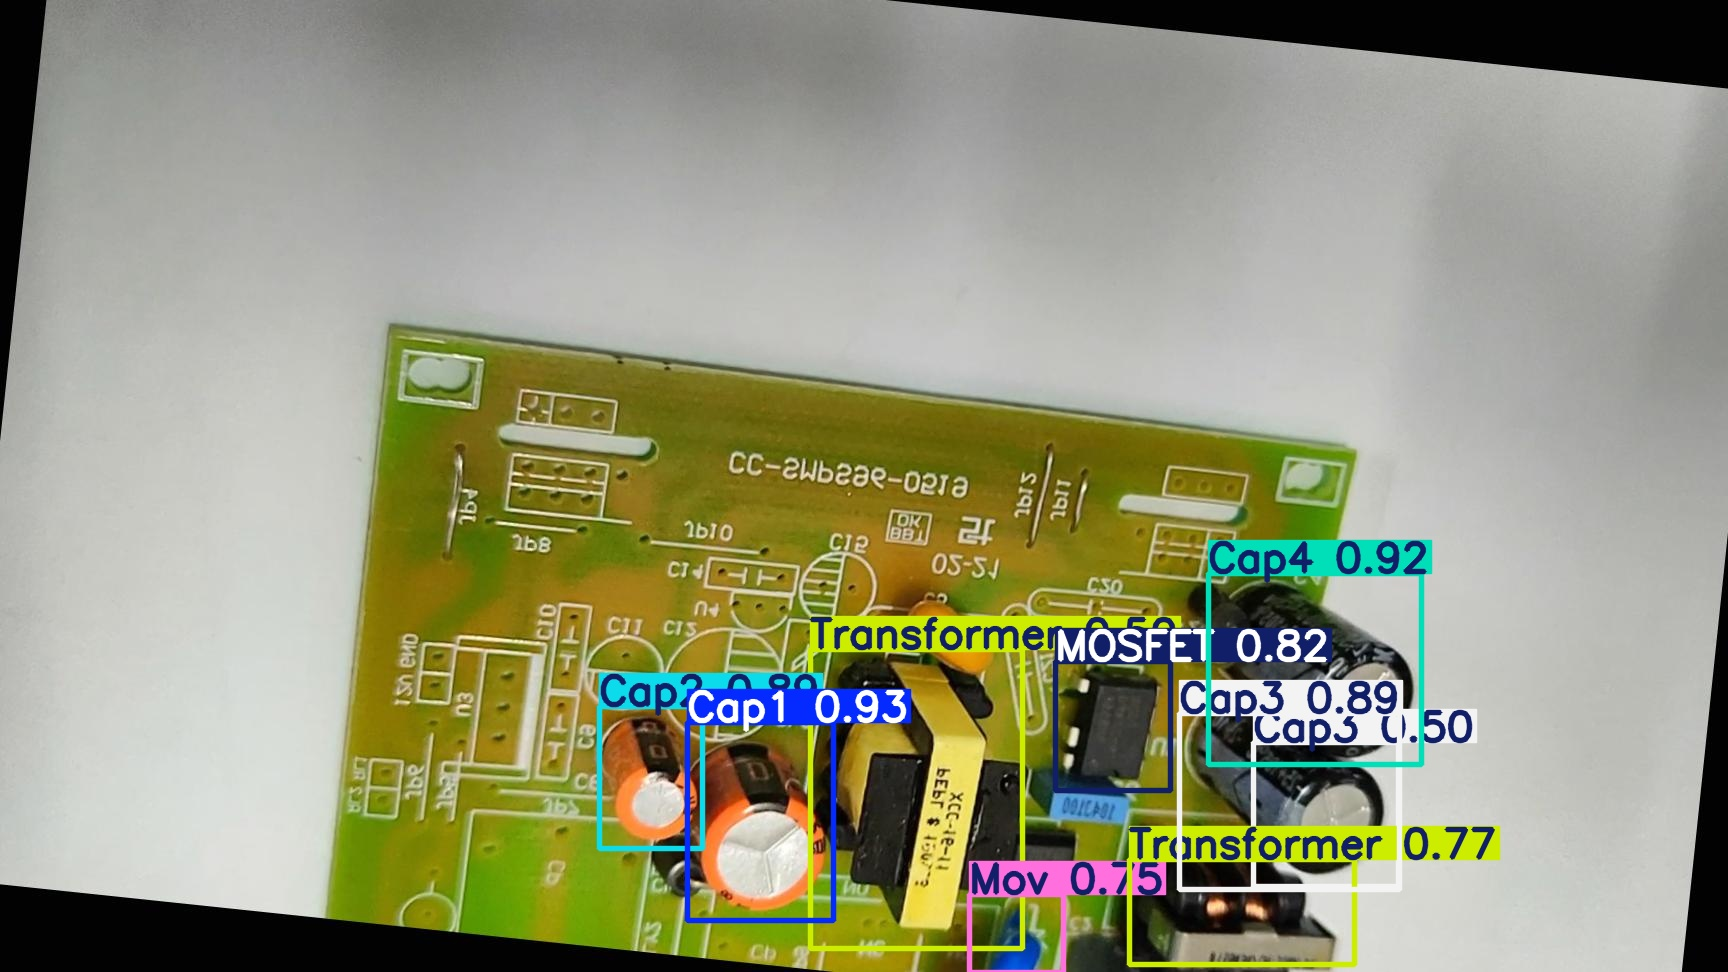

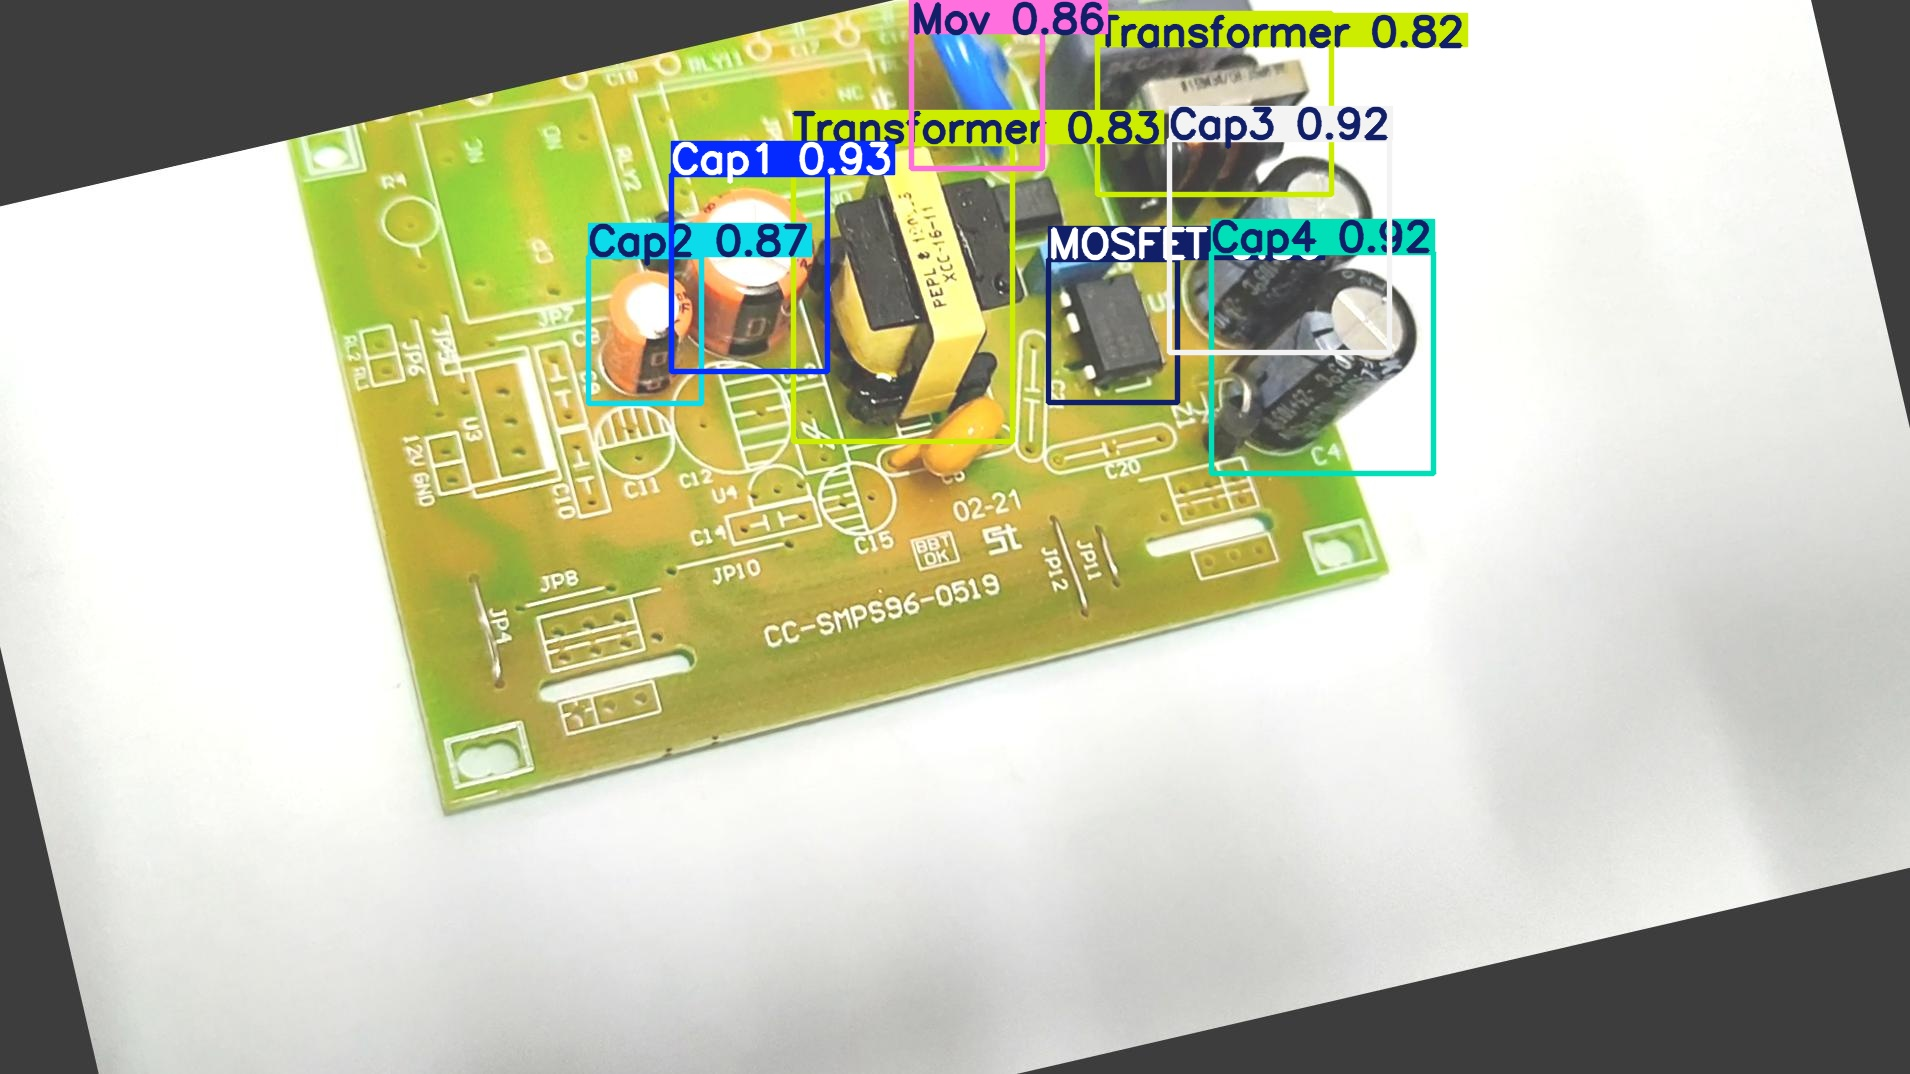

In [ ]:
import os
from IPython.display import Image, display

# 1. 예측 결과 폴더
predict_dir = "runs/detect/predict"

# 2. 폴더 안 이미지 파일 목록 가져오기
img_files = [f for f in os.listdir(predict_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# 3. 상위 5개 이미지 선택
img_files = img_files[:5]

# 4. 이미지 표시
for img_file in img_files:
    display(Image(filename=os.path.join(predict_dir, img_file)))


================================================================================

# 학습결과 드라이브에 올리기

-> 반복해서 학습하지 않도록 하게 함
================================================================================


■ 구글 드라이브로 마운트

드라이브에 저장하게 됨

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


■ 드라이브 colab_Backup파일에 학습파일 업로드

In [ ]:
import os

backup_path = "/content/drive/MyDrive/colab_backup"
if not os.path.exists(backup_path):
    os.makedirs(backup_path)
    print("백업 폴더 생성 완료!")
else:
    print("백업 폴더 이미 존재")

# Colab 전체 작업을 안전하게 Drive로 백업
!rsync -av --progress --exclude 'drive' /content/ /content/drive/MyDrive/colab_backup/


백업 폴더 이미 존재
sending incremental file list
./
yolov8n.pt
      6,549,796 100%  132.24MB/s    0:00:00 (xfr#1, to-chk=100/102)
.config/
.config/.last_opt_in_prompt.yaml
              3 100%    0.00kB/s    0:00:00 (xfr#2, to-chk=96/102)
.config/.last_survey_prompt.yaml
             36 100%   35.16kB/s    0:00:00 (xfr#3, to-chk=95/102)
.config/.last_update_check.json
            135 100%  131.84kB/s    0:00:00 (xfr#4, to-chk=94/102)
.config/active_config
              7 100%    6.84kB/s    0:00:00 (xfr#5, to-chk=93/102)
.config/config_sentinel
              0 100%    0.00kB/s    0:00:00 (xfr#6, to-chk=92/102)
.config/default_configs.db
         12,288 100%    5.86MB/s    0:00:00 (xfr#7, to-chk=91/102)
.config/gce
              5 100%    2.44kB/s    0:00:00 (xfr#8, to-chk=90/102)
.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
         12,288 100%    5.86MB/s    0:00:00 (xfr#9, to-chk=89/102)
.config/configurations/
.config/configurations/config_default
             94

In [ ]:
# @디버깅용
# 드라이브에 colab_backup파일에 제대로 업로드되어 생성됐는지 확인하는 코드
!ls /content/drive/MyDrive/colab_backup/ # 어떤 파일이 복사 됐는지 확인
print('-'*60)
!ls /content/drive/MyDrive/colab_backup/runs/detect/ # 학습된 결과파일 확인
print('-'*60)
!ls /content/drive/MyDrive/colab_backup/runs/detect/train_corrected/ # 학습된 결과파일 확인
print('-'*60)
!ls /content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/ # 가중치 파일 확인

dataset  kaggle.json  runs  sample_data  yolo26n.pt  yolov8n.pt
------------------------------------------------------------
predict  train_corrected
------------------------------------------------------------
args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2760.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch2761.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch2762.jpg  weights
labels.jpg			 train_batch2.jpg
------------------------------------------------------------
best.pt  last.pt


■ 드라이브에 올라간 파일로 검증파일 불러와보기

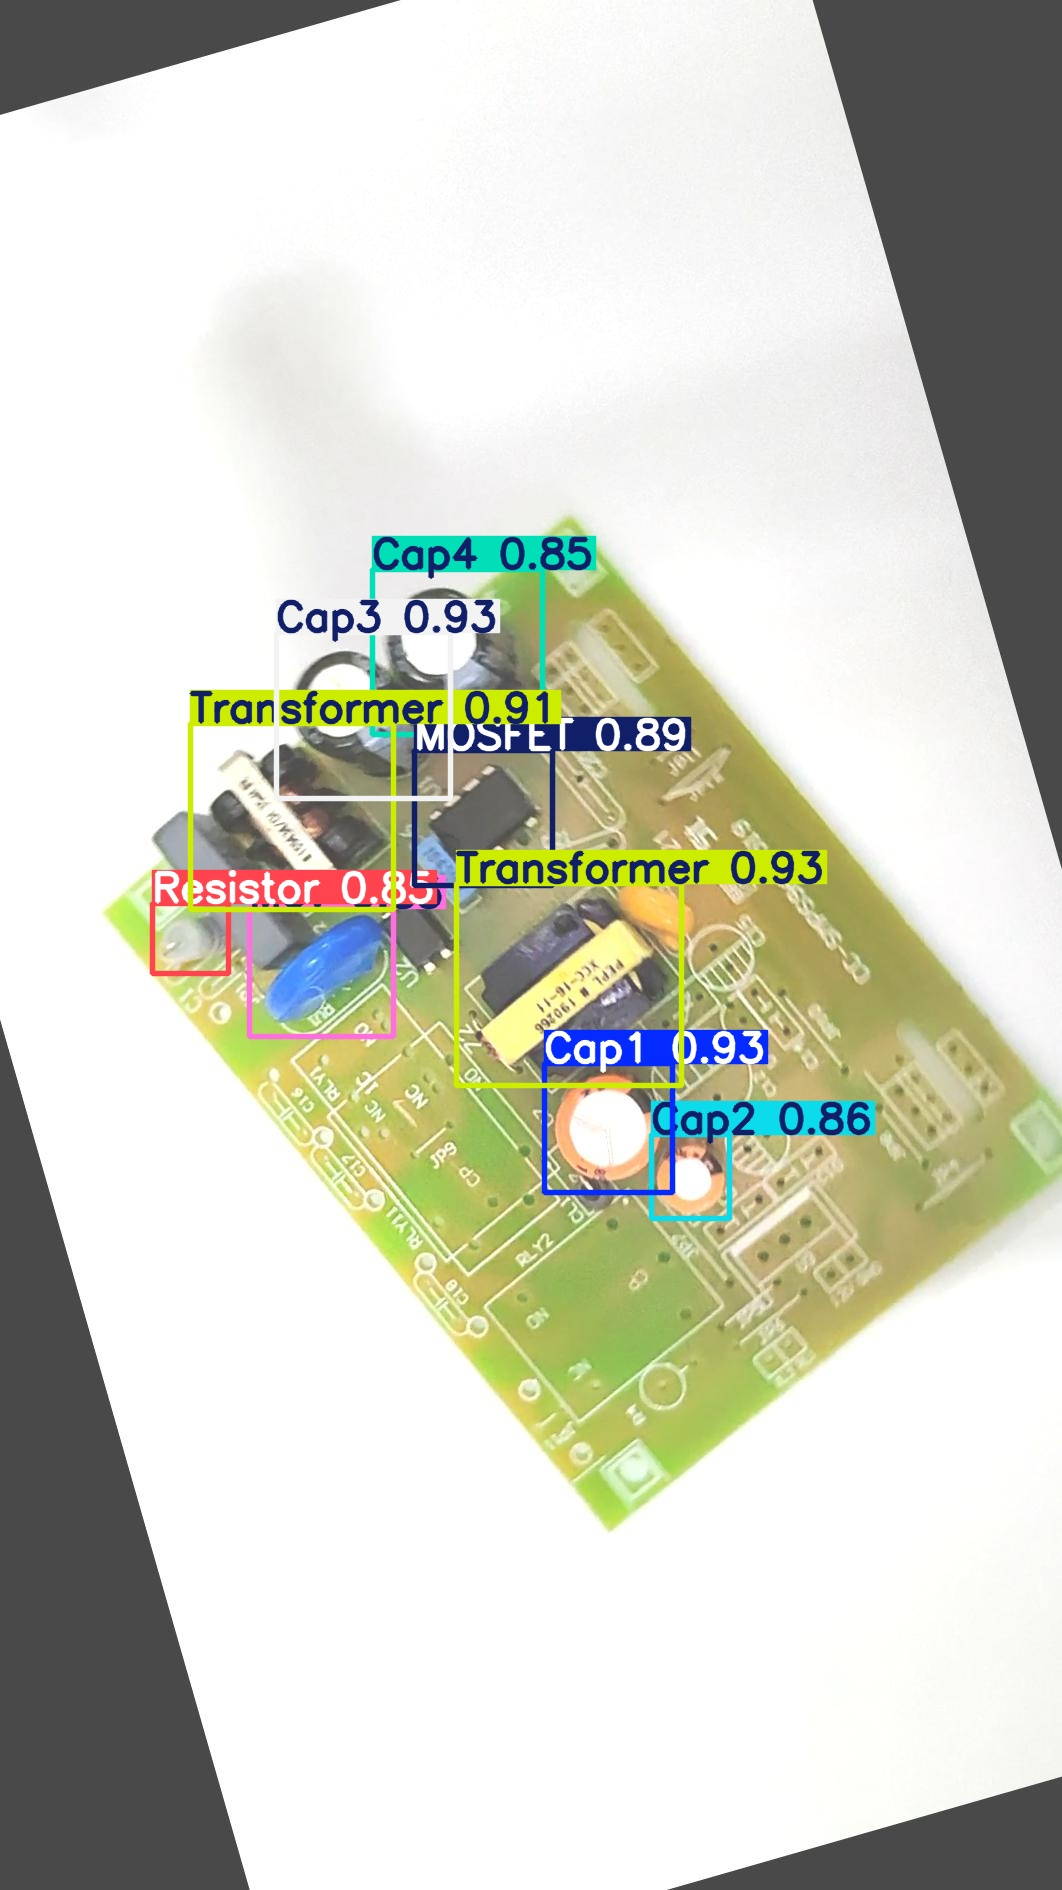

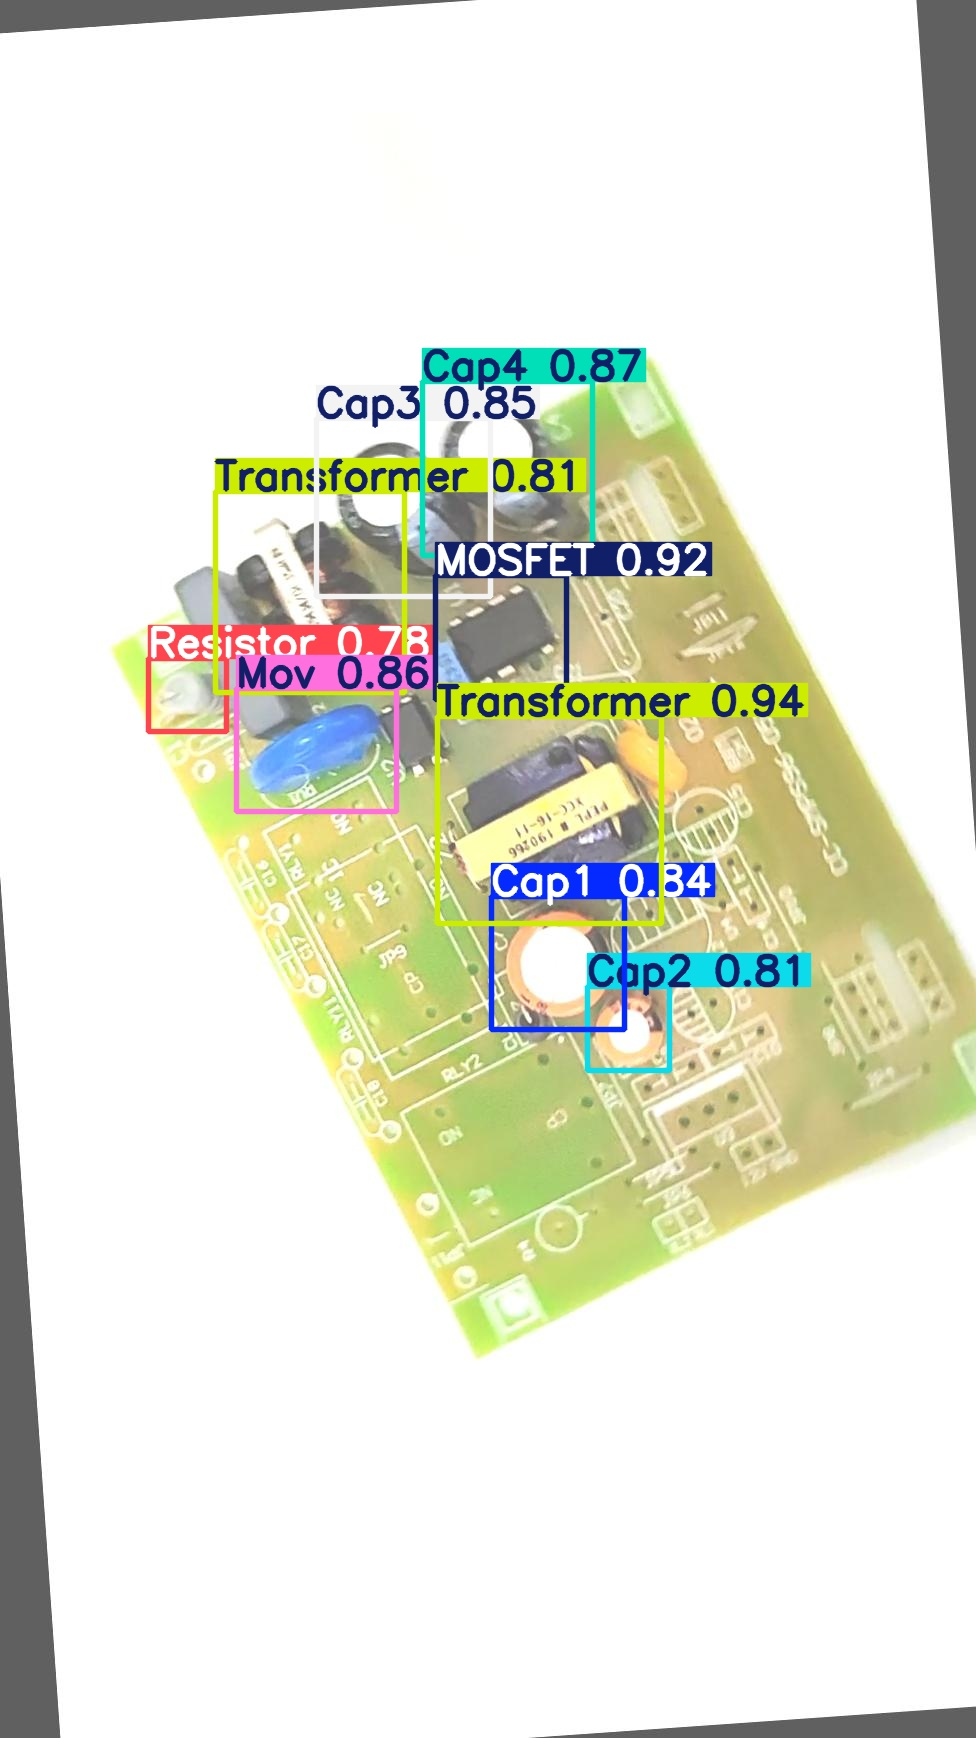

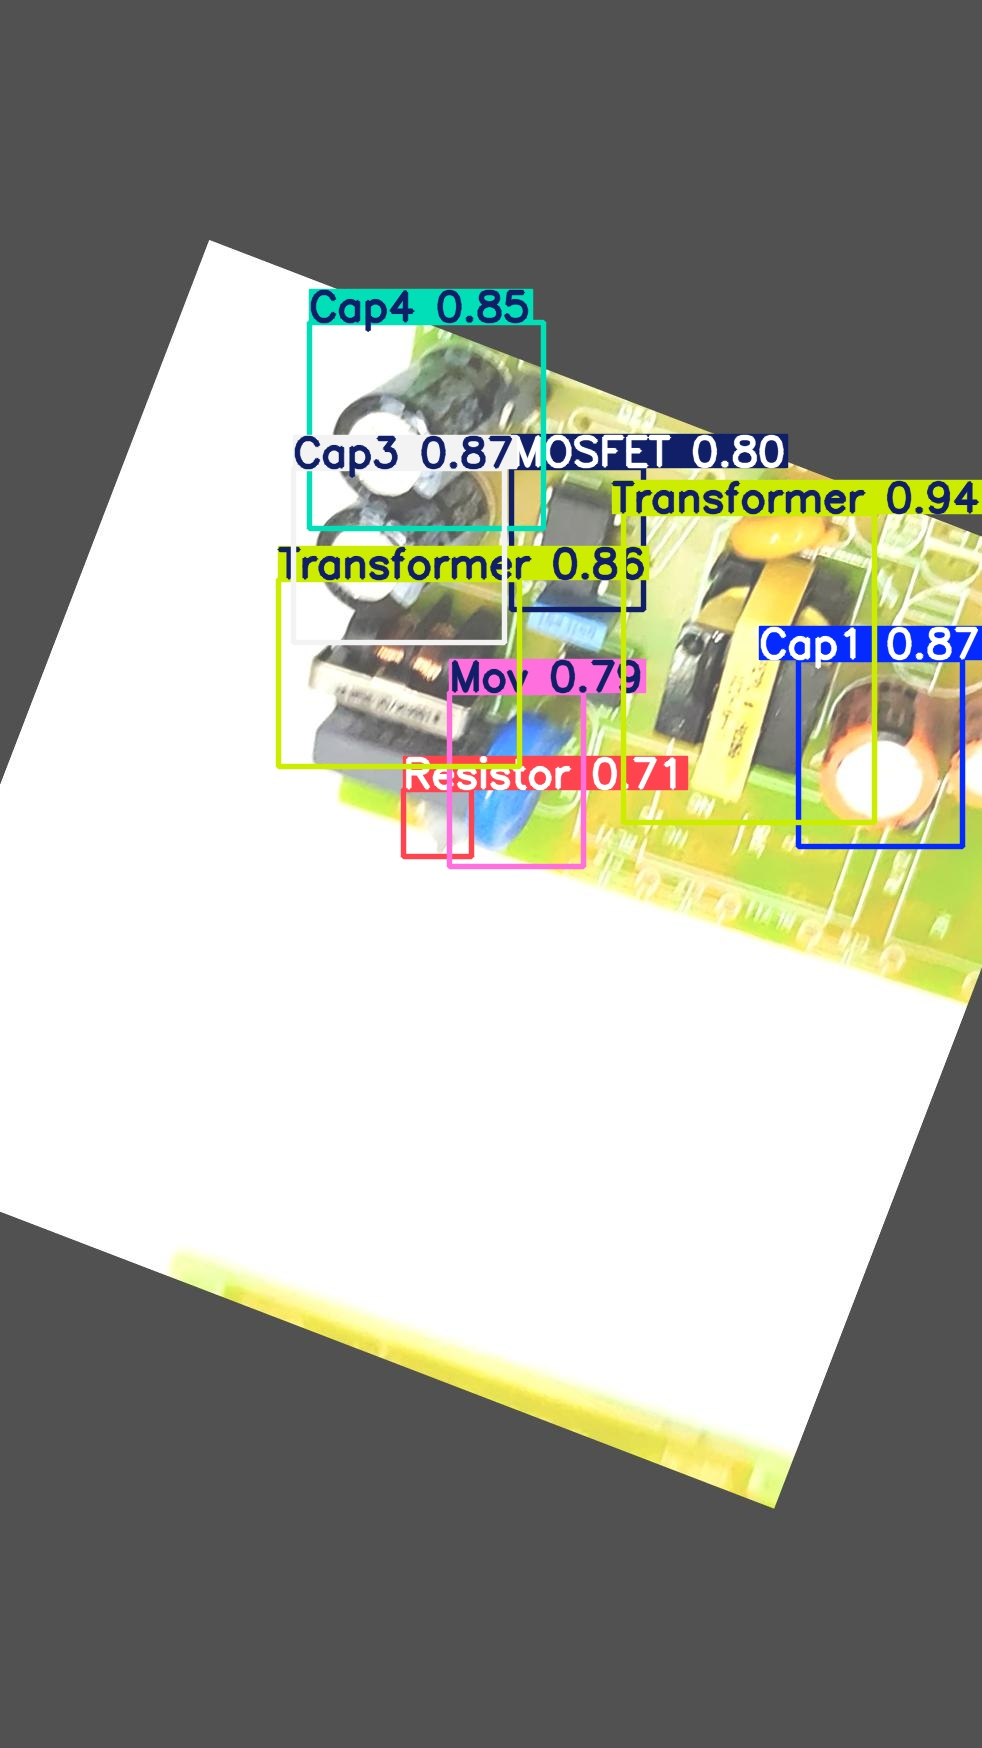

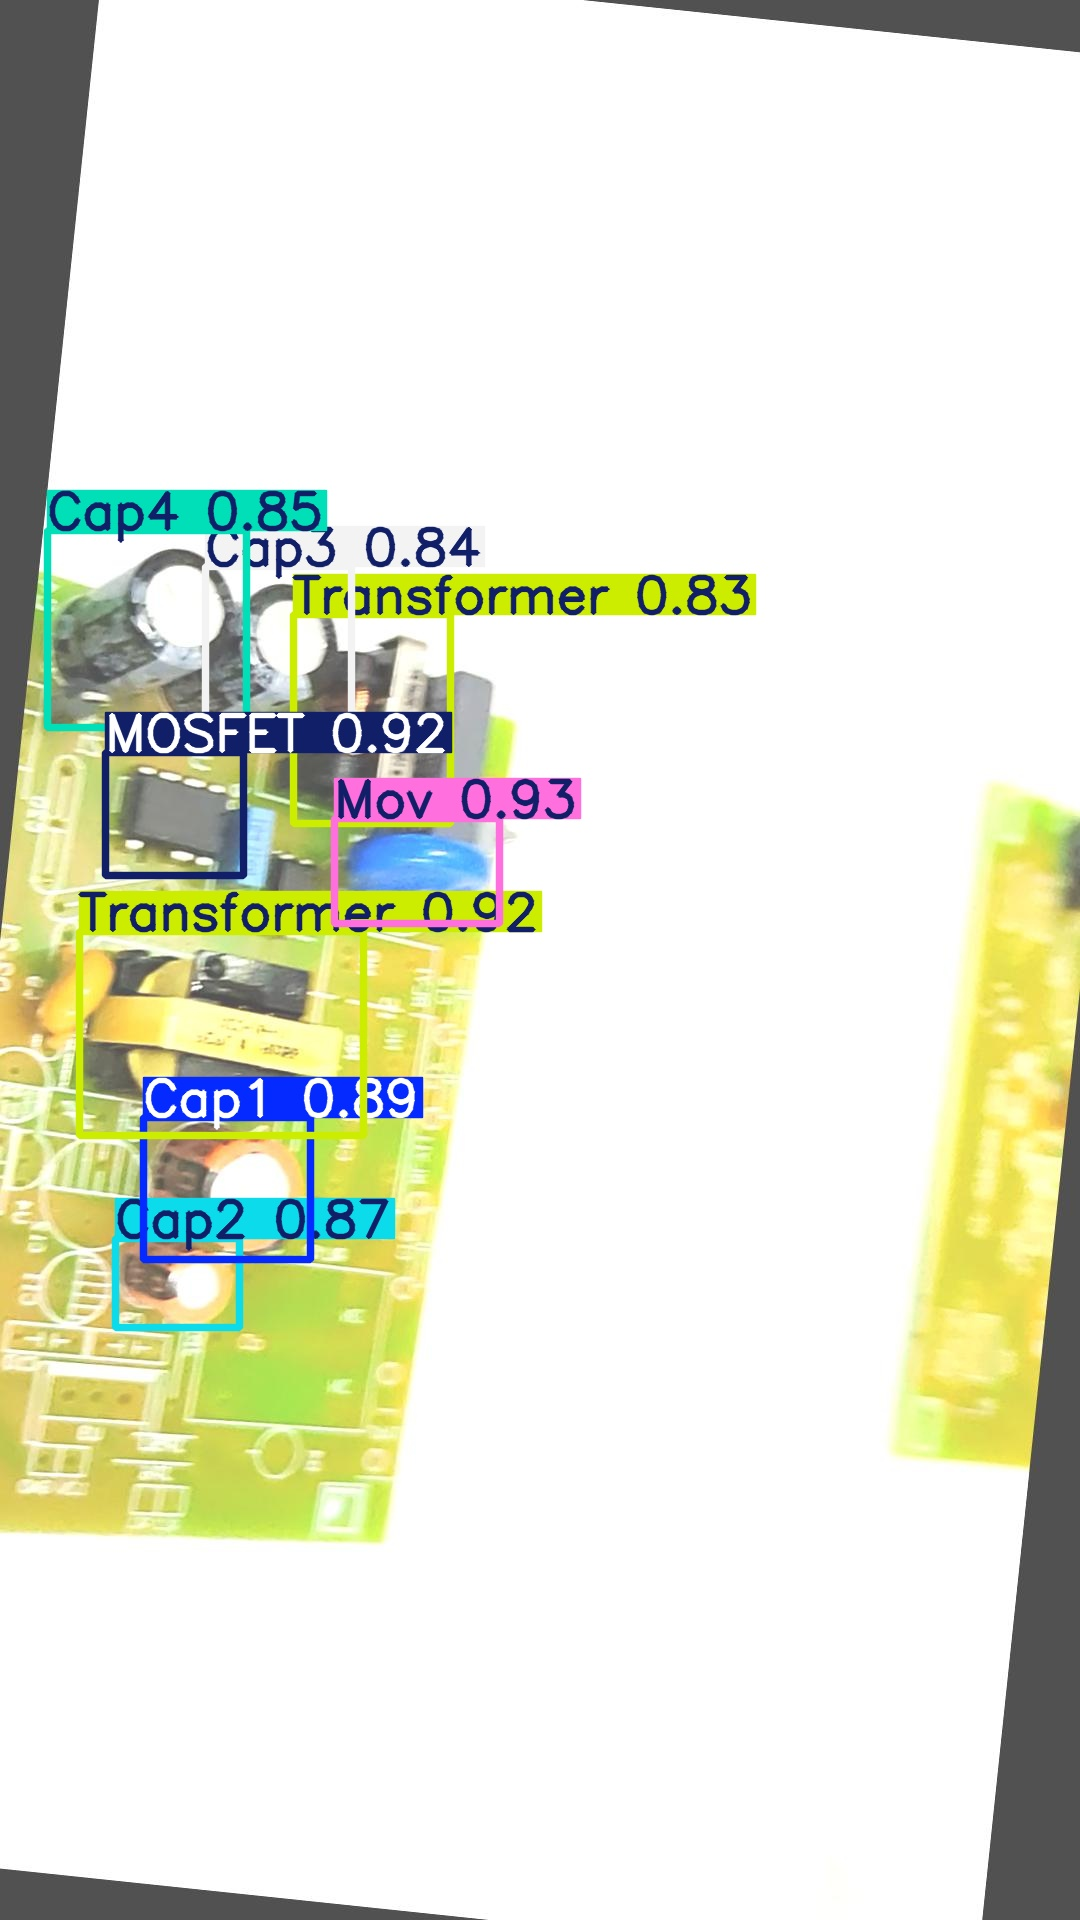

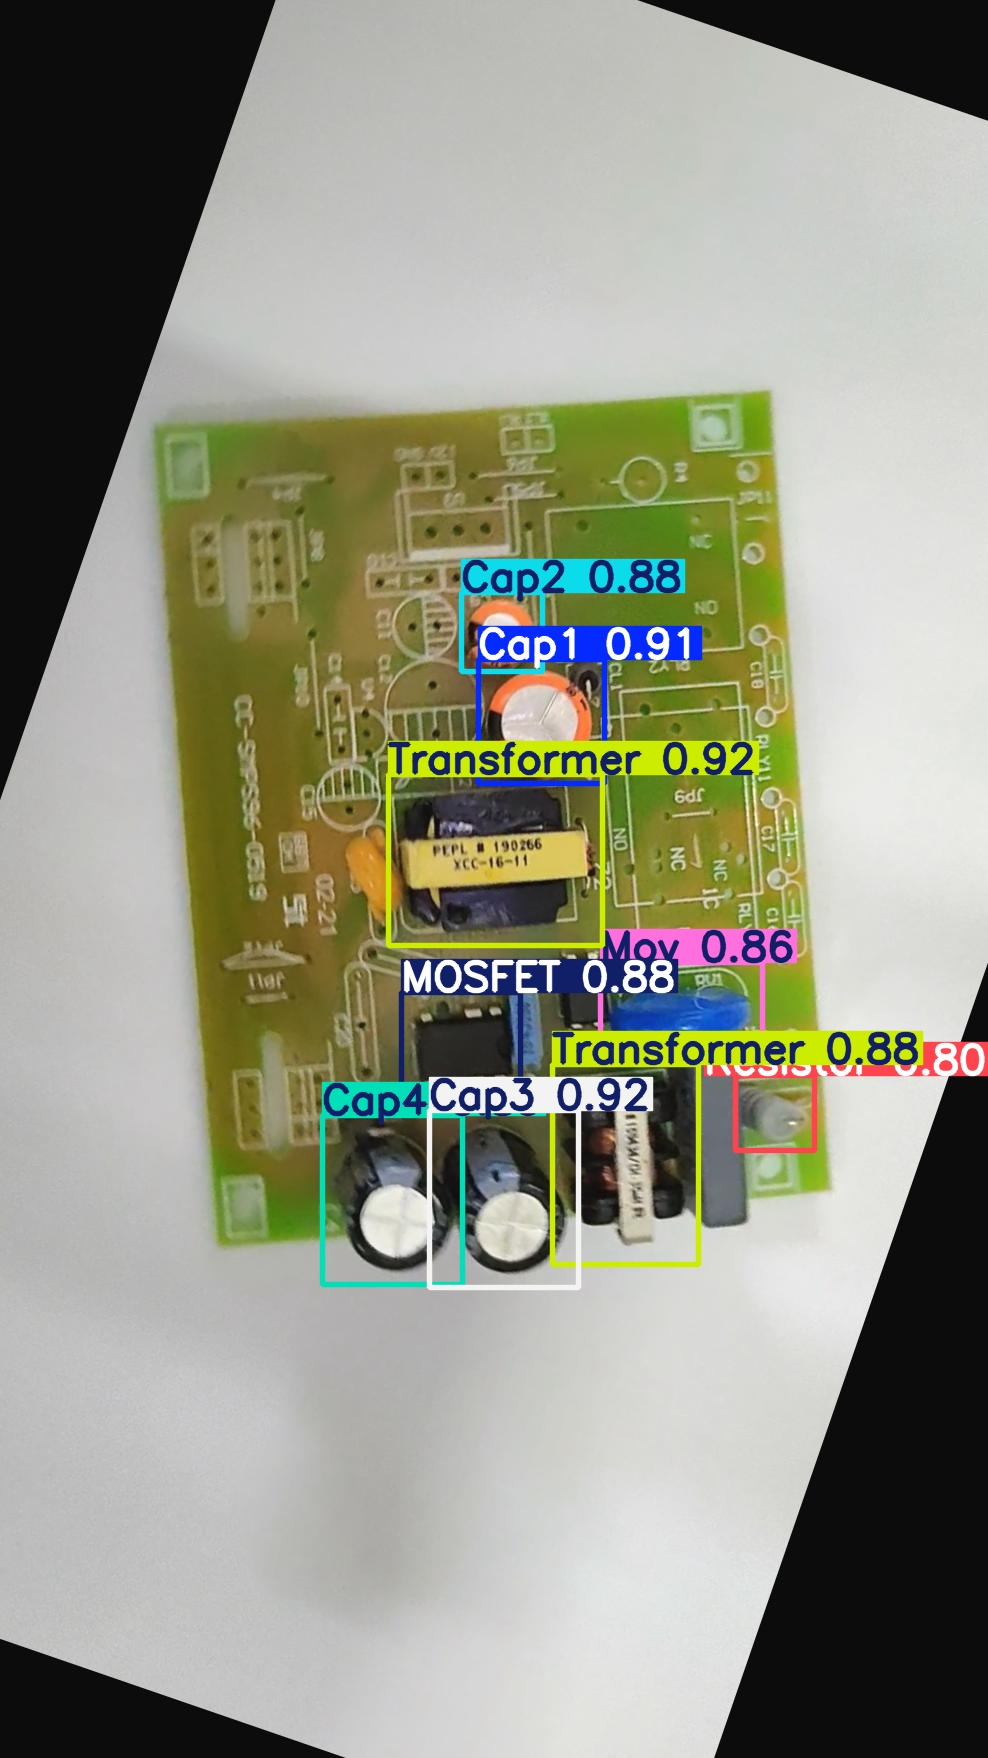

In [ ]:
import os
from IPython.display import Image, display

# 1. 예측 결과 폴더
predict_dir = "/content/drive/MyDrive/colab_backup/runs/detect/predict"

# 2. 폴더 안 이미지 파일 목록 가져오기
img_files = [f for f in os.listdir(predict_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

# 3. 상위 5개 이미지 선택
img_files = img_files[:5]

# 4. 이미지 표시
for img_file in img_files:
    display(Image(filename=os.path.join(predict_dir, img_file)))


■ 파일 경로 확인하기

drive에 올린 test 파일 경로 확인

In [ ]:
import os

# 가능한 경로들 확인
possible_paths = [
    '/content/drive/MyDrive/colab_backup/Data/test/images',
    '/content/drive/MyDrive/colab_backup/dataset/Data/test/images', # drive에 올린 파일 경로
    '/content/dataset/Data/test/images', # 기본 파일 경로 -> 매번 코드 실행 시켜서 생성되는 경로
]

print("🔍 경로 확인 중...\n")
for path in possible_paths:
    if os.path.exists(path):
        print(f"✅ 존재: {path}")
        img_count = len([f for f in os.listdir(path) if f.endswith(('.jpg', '.png', '.jpeg'))])
        print(f"   이미지: {img_count}개\n")
    else:
        print(f"❌ 없음: {path}\n")

🔍 경로 확인 중...

❌ 없음: /content/drive/MyDrive/colab_backup/Data/test/images

✅ 존재: /content/drive/MyDrive/colab_backup/dataset/Data/test/images
   이미지: 111개

❌ 없음: /content/dataset/Data/test/images



In [ ]:
from ultralytics import YOLO
from collections import defaultdict
import os

# 학습된 모델 로드
model = YOLO('/content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/best.pt')

# 클래스 이름
class_names = ['Cap1', 'Cap2', 'Cap3', 'Cap4', 'MOSFET', 'Mov', 'Resistor', 'Transformer', 'Resestor']

# Validation 이미지 폴더
val_images_dir = '/content/drive/MyDrive/colab_backup/dataset/Data/test/images'

# 예측 실행
results = model.predict(
    source=val_images_dir,
    conf=0.25,  # confidence threshold
    iou=0.45,   # NMS IoU threshold
    save=False,
    verbose=False
)

# 클래스별 검출 개수 집계
class_counts = defaultdict(int)
total_detections = 0

for result in results:
    boxes = result.boxes
    if boxes is not None:
        for box in boxes:
            class_id = int(box.cls[0])
            class_counts[class_id] += 1
            total_detections += 1

# 결과 출력
print("=" * 60)
print("📊 검출 결과 통계")
print("=" * 60)
print(f"\n총 검출 개수: {total_detections}개\n")
print("-" * 60)
print(f"{'클래스 ID':<12} {'클래스 이름':<15} {'검출 개수':<10} {'비율':<10}")
print("-" * 60)

for class_id in sorted(class_counts.keys()):
    class_name = class_names[class_id]
    count = class_counts[class_id]
    percentage = (count / total_detections * 100) if total_detections > 0 else 0
    print(f"{class_id:<12} {class_name:<15} {count:<10} {percentage:>6.2f}%")

print("-" * 60)

# 검출되지 않은 클래스 표시
detected_classes = set(class_counts.keys())
all_classes = set(range(len(class_names)))
missing_classes = all_classes - detected_classes

if missing_classes:
    print(f"\n⚠️  검출되지 않은 클래스: {', '.join([class_names[i] for i in sorted(missing_classes)])}")
else:
    print("\n✅ 모든 클래스가 검출되었습니다!")

print("=" * 60)

📊 검출 결과 통계

총 검출 개수: 992개

------------------------------------------------------------
클래스 ID       클래스 이름          검출 개수      비율        
------------------------------------------------------------
0            Cap1            111         11.19%
1            Cap2            109         10.99%
2            Cap3            113         11.39%
3            Cap4            109         10.99%
4            MOSFET          111         11.19%
5            Mov             113         11.39%
6            Resistor        105         10.58%
7            Transformer     221         22.28%
------------------------------------------------------------

⚠️  검출되지 않은 클래스: Resestor


# OpenCV 영상처리 코드

■ 영상처리를 위한 패키지 추가 설치하기

In [6]:
# 학습된 모델 파일 확인
import os

bestmodel = "/content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/best.pt" #가장 좋은 가중치
lastmodel = "/content/drive/MyDrive/colab_backup/runs/detect/train_corrected/weights/last.pt" #학습이 끝난 시점의 가중치
print(f"모델 존재: {os.path.exists(bestmodel)}")
print(f"모델 존재: {os.path.exists(lastmodel)}")

모델 존재: True
모델 존재: True


In [ ]:
# 1
# ▶ 기존 영상 판별 ➜ 결과가 불안정/이상이면, 해당 프레임만 180도 회전 후 재추론
# ▷ 이상 기준 : 최근 평균 대비 검출 수의 급변
#              박스들의 평균 confidence가 낮을 때
#              Cap3 / Cap4 가 직전 프레임에는 있었으나, 이번 프레임에서는 소실될 때

# ▶ MOV 오탐/중복 잦음 ➜ MOV 클래스만 '근접 중복 제거' 후처리 적용
# ➜ 최종결과 conf 필터링 후 저장 + MOV 만 추가로 정리

# ※ 검출량은 좀 있는듯하지만, 판넬 밖에서도 검출 (오검출)이 많은 편
# ▶ 코드 수정 필요

# 1. cap3,4만이 아닌 각 클래스로 변경
# 2. 판넬 밖의 오검출 ➜ PCB HSV 마스크로 판넬 밖 박스 제거
# 3. plot값 그리고 뒤집힘 보완 (오검출 좀 있음)

from ultralytics import YOLO
import cv2
from google.colab import files
import numpy as np
import torch
from collections import Counter

# ==============================
# 0) 경로 설정
# ==============================
BASE = '/content/drive/MyDrive/colab_backup'
BEST_MODEL = f'{BASE}/runs/detect/train_corrected/weights/best.pt'

print("🤖 모델 로딩 중...")
model = YOLO(BEST_MODEL)
print("✅ 모델 로드 완료!\n")

# ==============================
# 1) 비디오 업로드
# ==============================
print("📹 비디오 파일을 업로드하세요:")
uploaded = files.upload()
video_file = list(uploaded.keys())[0]
print(f"\n✅ 업로드 완료: {video_file}\n")

cap = cv2.VideoCapture(video_file)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps <= 0:
    fps = 30 # fps 비정상일 경우, 안전값으로 대체

# ==============================
# 2) 출력 설정
# ==============================
output_file = 'output_detected_stable.movfix.clean.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, fps, (width, height))

print("🔄 처리 중...\n")

# ==============================
# 3) 추론 파라미터 (안정형)
# ==============================
IMG_SIZE = 960       # YOLO 입력크기
IOU_TH = 0.40        # 중복제거

CONF_0 = 0.10        # 0° 추론 
CONF_180 = 0.20      # 180° 재추론 (조금 높게 설정 -> 불안정 프레임 보정)

CONF_FILTER = 0.25   # 최종 표시/저장
CONF_GOOD = 0.25     # 0° vs 180° 선택, “좋은 박스” 기준

# ==============================
# 4) 전처리 
# 샤픈 제거, CLAHE 약하게
# ① 평균 밝기 기반 감마 보정(과노출/저노출 완화)
# ② 약한 CLAHE(뿌연 영상 대비 개선)
# ③ 샤픈 미적용(노이즈/가짜 엣지로 오탐 증가 방지)
# ==============================
def adjust_gamma(image, gamma=1.0):
    inv = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(image, table)

def apply_clahe_bgr(image, clip=1.5, grid=(8, 8)):
    # gamma 보정 LUT 생성 후 적용
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_for_infer(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mean_brightness = float(np.mean(gray))

    if mean_brightness > 185:
        frame = adjust_gamma(frame, gamma=1.25)
    elif mean_brightness < 65:
        frame = adjust_gamma(frame, gamma=0.8)

    return apply_clahe_bgr(frame, clip=1.5, grid=(8, 8))

# ==============================
# 180° 박스 좌표 역변환
# ==============================
def inverse_boxes_180_inplace(results, w: int, h: int):
    if results.boxes is None or len(results.boxes) == 0:
        return results

    boxes = results.boxes
    d = boxes.data.clone()  # ← clone 필수 (InferenceMode 해결)

    x1 = d[:, 0].clone()
    y1 = d[:, 1].clone()
    x2 = d[:, 2].clone()
    y2 = d[:, 3].clone()

    new_x1 = (w - 1) - x2
    new_y1 = (h - 1) - y2
    new_x2 = (w - 1) - x1
    new_y2 = (h - 1) - y1

    new_x1 = new_x1.clamp(0, w - 1)
    new_x2 = new_x2.clamp(0, w - 1)
    new_y1 = new_y1.clamp(0, h - 1)
    new_y2 = new_y2.clamp(0, h - 1)

    d[:, 0] = torch.minimum(new_x1, new_x2)
    d[:, 1] = torch.minimum(new_y1, new_y2)
    d[:, 2] = torch.maximum(new_x1, new_x2)
    d[:, 3] = torch.maximum(new_y1, new_y2)

    boxes.data = d
    results.boxes = boxes
    return results

# ==============================
# PCB 마스크
# ==============================
PCB_LOWER = np.array([10, 25, 25], dtype=np.uint8)
PCB_UPPER = np.array([80, 255, 255], dtype=np.uint8)

def build_pcb_mask(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, PCB_LOWER, PCB_UPPER)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9,9))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, 2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, 1)

    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None

    c = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    h, w = mask.shape[:2]

    if area < 0.08 * (h*w):
        return None

    pcb_mask = np.zeros_like(mask)
    cv2.drawContours(pcb_mask, [c], -1, 255, -1)
    return pcb_mask

def filter_boxes_outside_pcb(results, pcb_mask):
    if results.boxes is None or len(results.boxes) == 0:
        return results

    xyxy = results.boxes.xyxy
    h, w = pcb_mask.shape[:2]
    keep = []

    for box in xyxy:
        x1,y1,x2,y2 = box.cpu().numpy().astype(int)
        x1 = max(0,min(w-1,x1)); x2 = max(0,min(w-1,x2))
        y1 = max(0,min(h-1,y1)); y2 = max(0,min(h-1,y2))
        roi = pcb_mask[y1:y2, x1:x2]
        keep.append(roi.mean() > 2)

    keep_t = torch.tensor(keep, device=xyxy.device)
    results.boxes = results.boxes[keep_t]
    return results

# ==============================
# 이상 프레임 감지 변수
# ==============================
recent_counts = []
frame_count = 0
detection_count = 0

def good_box_count(res, th=0.25):
    if res.boxes is None:
        return 0
    return int((res.boxes.conf >= th).sum().item())

# ==============================
# 7) 프레임 루프
# ==============================
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    frame_orig = frame.copy()
    pcb_mask = build_pcb_mask(frame_orig)

    # 0도 추론
    res0 = model.predict(
        preprocess_for_infer(frame_orig),
        imgsz=IMG_SIZE,
        conf=CONF_0,
        iou=IOU_TH,
        verbose=False
    )[0]

    count0 = len(res0.boxes) if res0.boxes is not None else 0
    mean_conf0 = float(res0.boxes.conf.mean()) if count0 > 0 else 0

    is_abnormal = False

    if len(recent_counts) >= 5:
        avg = np.mean(recent_counts[-5:])
        if count0 < avg * 0.5 or count0 > avg * 1.5:
            is_abnormal = True

    if mean_conf0 < 0.25:
        is_abnormal = True

    chosen = res0
    used_180 = False

    # 180° 재추론
    if is_abnormal:
        frame180 = cv2.rotate(frame_orig, cv2.ROTATE_180)
        res180 = model.predict(
            preprocess_for_infer(frame180),
            imgsz=IMG_SIZE,
            conf=CONF_180,
            iou=IOU_TH,
            verbose=False
        )[0]

        if good_box_count(res180) > good_box_count(res0):
            chosen = res180
            used_180 = True
            chosen = inverse_boxes_180_inplace(chosen, width, height)

    # PCB 필터
    if pcb_mask is not None:
        chosen = filter_boxes_outside_pcb(chosen, pcb_mask)

    # 최종 conf 필터
    if chosen.boxes is not None:
        chosen.boxes = chosen.boxes[chosen.boxes.conf >= CONF_FILTER]

    # 항상 원본 위에 plot (색상 기본값 유지)
    annotated_frame = chosen.plot(img=frame_orig.copy())

    out.write(annotated_frame)
    detection_count += len(chosen.boxes) if chosen.boxes is not None else 0
    recent_counts.append(count0)

    # 로그 (30 프레임마다 출력)
    if frame_count % 30 == 0:
        progress = (frame_count / total_frames) * 100 if total_frames > 0 else 0
        print(
            f"📍 진행: {progress:.1f}% ({frame_count}/{total_frames}) "
            f"- 0°검출:{count0}(필터전) / 최종:{final_count} / MOV:{final_mov} "
            f"/ mean_conf0:{mean_conf0:.2f} / abnormal:{is_abnormal}"
        )

cap.release()
out.release()

print(f"\n✅ 처리 완료!")
print(f"📁 출력 파일: {output_file}")
print(f"🔍 총 최종 표시 검출 횟수: {detection_count}개")

print("\n💾 결과 다운로드 중...")
files.download(output_file)
print("✅ 다운로드 완료!")

🤖 모델 로딩 중...
✅ 모델 로드 완료!

📹 비디오 파일을 업로드하세요:


Saving pbc_img_record.mp4 to pbc_img_record.mp4

✅ 업로드 완료: pbc_img_record.mp4

🔄 처리 중...

📍 진행: 27.0% (30/111) - 0°검출:3(필터전) / 최종:1 / MOV:1 / mean_conf0:0.35 / abnormal:True
📍 진행: 54.1% (60/111) - 0°검출:4(필터전) / 최종:2 / MOV:1 / mean_conf0:0.37 / abnormal:True
📍 진행: 81.1% (90/111) - 0°검출:9(필터전) / 최종:8 / MOV:1 / mean_conf0:0.76 / abnormal:False

✅ 처리 완료!
📁 출력 파일: output_detected_stable.movfix.clean.mp4
🔍 총 최종 표시 검출 횟수: 693개

💾 결과 다운로드 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 완료!


In [ ]:
# 2
# ▶ 차이 (임계치도 다름)
# ▷ 위의 코드는 샤픈 제거, CLAHE 약하게
#             이상 프레임 180도 돌려, 좋은 박스의 개수로 비교 (동률 시 평균 conf로 비교)
# ▷ 이 코드는 샤픈 적용, CLAHE 더 강하게, 감마도 세게 (선명함을 기준)
#             이상 프레임 180도 돌려, 박스 개수 많은 쪽 선택

from ultralytics import YOLO
import cv2
from google.colab import files
import numpy as np
import torch
from collections import Counter

# ==============================
# 0) 경로 설정
# ==============================
BASE = '/content/drive/MyDrive/colab_backup'
BEST_MODEL = f'{BASE}/runs/detect/train_corrected/weights/best.pt'

print("🤖 모델 로딩 중...")
model = YOLO(BEST_MODEL)
print("✅ 모델 로드 완료!\n")

# ==============================
# 1) 비디오 업로드
# ==============================
print("📹 비디오 파일을 업로드하세요:")
uploaded = files.upload()
video_file = list(uploaded.keys())[0]
print(f"\n✅ 업로드 완료: {video_file}\n")

cap = cv2.VideoCapture(video_file)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps <= 0:
    fps = 30

# ==============================
# 2) 출력 비디오 설정
# ==============================
output_file = 'output_detected_smart_preprocess_movfix_cleanview.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, fps, (width, height))

print("🔄 처리 중...\n")

# ==============================
# 3) 추론 파라미터
# ==============================
IMG_SIZE = 960
IOU_TH = 0.45
CONF_0 = 0.12
CONF_180 = 0.20
CONF_FILTER = 0.20

# ==============================
# 4) 전처리 함수 (추론용만!)
# ==============================
def adjust_gamma(image, gamma=1.0):
    inv = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(image, table)

def apply_clahe_bgr(image, clip=2.0, grid=(8, 8)):
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
    l2 = clahe.apply(l)
    lab2 = cv2.merge((l2, a, b))
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def sharpen(image):
    kernel = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]], dtype=np.float32)
    return cv2.filter2D(image, -1, kernel)

def preprocess_for_infer(frame):
    """사람이 보는 화질이 아니라, 모델 입력용 프레임만 보정"""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mean_brightness = float(np.mean(gray))

    if mean_brightness > 180:
        frame = adjust_gamma(frame, gamma=1.4)
    elif mean_brightness < 70:
        frame = adjust_gamma(frame, gamma=0.7)

    frame = apply_clahe_bgr(frame, clip=2.0, grid=(8, 8))
    frame = sharpen(frame)
    return frame

# ==============================
# 5) MOV 전용 후처리
# ==============================
MOV_STRICT = 0.28
PROX_K = 0.6

def find_class_id_by_name(names_dict, target):
    t = target.strip().lower()
    for cid, cname in names_dict.items():
        if str(cname).strip().lower() == t:
            return int(cid)
    return None

MOV_CID = find_class_id_by_name(model.names, "Mov")
CAP3_CID = find_class_id_by_name(model.names, "Cap3")
CAP4_CID = find_class_id_by_name(model.names, "Cap4")

def mov_proximity_dedup(xyxy: np.ndarray, conf: np.ndarray, strict_th: float, prox_k: float):
    n = len(xyxy)
    if n <= 1:
        return np.arange(n, dtype=int)

    cx = (xyxy[:, 0] + xyxy[:, 2]) / 2.0
    cy = (xyxy[:, 1] + xyxy[:, 3]) / 2.0

    w = np.maximum(1.0, xyxy[:, 2] - xyxy[:, 0])
    h = np.maximum(1.0, xyxy[:, 3] - xyxy[:, 1])
    base = np.minimum(w, h)

    score = conf + (conf >= strict_th).astype(np.float32) * 0.05
    order = np.argsort(-score)

    suppressed = np.zeros(n, dtype=bool)
    keep = []

    for i in order:
        if suppressed[i]:
            continue
        keep.append(i)

        th = prox_k * base[i]
        dx = cx - cx[i]
        dy = cy - cy[i]
        dist = np.sqrt(dx * dx + dy * dy)

        close = dist < th
        suppressed |= close
        suppressed[i] = False

    return np.array(keep, dtype=int)

def apply_final_filters_with_mov(results, conf_filter: float):
    if results.boxes is None or len(results.boxes) == 0:
        return results, 0, 0

    # 1) 전체 conf 필터
    keep_mask = results.boxes.conf >= conf_filter
    if keep_mask.sum().item() == 0:
        results.boxes = results.boxes[:0]
        return results, 0, 0
    results.boxes = results.boxes[keep_mask]

    # 2) MOV 근접 중복 제거
    if MOV_CID is None or results.boxes is None or len(results.boxes) == 0:
        return results, len(results.boxes), 0

    cls = results.boxes.cls.to(torch.int64)
    mov_idx = torch.where(cls == MOV_CID)[0]
    if len(mov_idx) <= 1:
        mov_count = int(len(mov_idx))
        return results, len(results.boxes), mov_count

    mov_xyxy = results.boxes.xyxy[mov_idx].cpu().numpy()
    mov_conf = results.boxes.conf[mov_idx].cpu().numpy()

    kept_local = mov_proximity_dedup(mov_xyxy, mov_conf, strict_th=MOV_STRICT, prox_k=PROX_K)
    mov_keep_global = mov_idx[torch.tensor(kept_local, dtype=torch.long)]

    non_mov_idx = torch.where(cls != MOV_CID)[0]
    final_idx = torch.cat([non_mov_idx, mov_keep_global], dim=0)
    final_idx, _ = torch.sort(final_idx)

    results.boxes = results.boxes[final_idx]
    mov_count = int(torch.sum(results.boxes.cls.to(torch.int64) == MOV_CID).item())
    return results, len(results.boxes), mov_count

# 180
# ==============================
# 6) 이상 프레임 판단용 상태
# ==============================
recent_counts = []
recent_cap_presence = True

frame_count = 0
detection_count = 0

# ==============================
# 7) 프레임 루프
# ==============================
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    frame_orig = frame  # 저장/표시는 원본 사용

    # 0° 추론은 전처리된 프레임으로
    frame_p = preprocess_for_infer(frame_orig)
    res0 = model.predict(frame_p, imgsz=IMG_SIZE, conf=CONF_0, iou=IOU_TH, verbose=False)[0]

    boxes0 = res0.boxes
    count0 = len(boxes0) if boxes0 is not None else 0

    if boxes0 is not None and len(boxes0) > 0:
        mean_conf0 = float(boxes0.conf.mean().item())
        cls_ids0 = boxes0.cls.cpu().numpy().astype(int)
        cls_counter0 = Counter(cls_ids0)
    else:
        mean_conf0 = 0.0
        cls_counter0 = Counter()

    # 이상 판정
    is_abnormal = False

    if len(recent_counts) >= 5:
        avg_count = float(np.mean(recent_counts[-5:]))
        if count0 < avg_count * 0.5 or count0 > avg_count * 1.5:
            is_abnormal = True

    if mean_conf0 < 0.25:
        is_abnormal = True

    cap_present_now = False
    if CAP3_CID is not None and cls_counter0.get(CAP3_CID, 0) > 0:
        cap_present_now = True
    if CAP4_CID is not None and cls_counter0.get(CAP4_CID, 0) > 0:
        cap_present_now = True

    if recent_cap_presence and not cap_present_now:
        is_abnormal = True

    # 필요 시 180° 재추론(전처리된 180 프레임)
    chosen = res0
    chosen_count_prefilter = count0

    if is_abnormal:
        frame180 = cv2.rotate(frame_orig, cv2.ROTATE_180)
        frame180_p = preprocess_for_infer(frame180)
        res180 = model.predict(frame180_p, imgsz=IMG_SIZE, conf=CONF_180, iou=IOU_TH, verbose=False)[0]
        count180 = len(res180.boxes) if res180.boxes is not None else 0

        if count180 > chosen_count_prefilter:
            chosen = res180
            chosen_count_prefilter = count180

    # 최종 conf 필터 + MOV 정리
    chosen, final_count, final_mov = apply_final_filters_with_mov(chosen, conf_filter=CONF_FILTER)

    # 출력은 "원본" 위에 박스만 → '화질유지' 위함
    try:
        annotated_frame = chosen.plot(img=frame_orig.copy())
    except TypeError:
        # plot(img=...)가 안되는 버전 대비
        annotated_frame = chosen.plot()

    out.write(annotated_frame)
    detection_count += final_count

    recent_counts.append(count0)
    recent_cap_presence = cap_present_now

    if frame_count % 30 == 0:
        progress = (frame_count / total_frames) * 100 if total_frames > 0 else 0
        print(
            f"📍 진행: {progress:.1f}% ({frame_count}/{total_frames}) "
            f"- 0°검출:{count0}(필터전) / 최종표시:{final_count} / MOV:{final_mov} "
            f"/ mean_conf0:{mean_conf0:.2f} / abnormal:{is_abnormal}"
        )

cap.release()
out.release()

print(f"\n✅ 처리 완료!")
print(f"📁 출력 파일: output_detected_smart_preprocess_movfix_cleanview.mp4")
print(f"🔍 총 최종 표시 검출 횟수: {detection_count}개")

print("\n💾 결과 다운로드 중...")
files.download("output_detected_smart_preprocess_movfix_cleanview.mp4")
print("✅ 다운로드 완료!")


🤖 모델 로딩 중...
✅ 모델 로드 완료!

📹 비디오 파일을 업로드하세요:


Saving pbc_img_record.mp4 to pbc_img_record (1).mp4

✅ 업로드 완료: pbc_img_record (1).mp4

🔄 처리 중...

📍 진행: 27.0% (30/111) - 0°검출:1(필터전) / 최종표시:1 / MOV:1 / mean_conf0:0.85 / abnormal:True
📍 진행: 54.1% (60/111) - 0°검출:2(필터전) / 최종표시:2 / MOV:1 / mean_conf0:0.49 / abnormal:False
📍 진행: 81.1% (90/111) - 0°검출:6(필터전) / 최종표시:6 / MOV:1 / mean_conf0:0.89 / abnormal:True

✅ 처리 완료!
📁 출력 파일: output_detected_smart_preprocess_movfix_cleanview.mp4
🔍 총 최종 표시 검출 횟수: 557개

💾 결과 다운로드 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 완료!


In [9]:
# 3
# 기본 형태

from ultralytics import YOLO
import cv2
from google.colab import files
import os

# ============== 경로 설정 ==============
BASE = '/content/drive/MyDrive/colab_backup'
BEST_MODEL = f'{BASE}/runs/detect/train_corrected/weights/best.pt'

# 모델 로드
print("🤖 모델 로딩 중...")
model = YOLO(BEST_MODEL)
print("✅ 모델 로드 완료!\n")

# ============== 비디오 업로드 ==============
print("📹 비디오 파일을 업로드하세요:")
uploaded = files.upload()

video_file = list(uploaded.keys())[0]
print(f"\n✅ 업로드 완료: {video_file}\n")

# ============== 비디오 처리 ==============
cap = cv2.VideoCapture(video_file)

# 비디오 정보
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


# 출력 비디오 설정
output_file = 'output_detected.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, fps, (width, height))

print("🔄 처리 중...\n")

frame_count = 0
detection_count = 0

IMG_SIZE = 960 # ▶ 해상도 (1280 - 제대로 인식 x)
CONF_TH = 0.15 # ▶ 임계값. 흔들림/밝기
IOU_TH = 0.45 # ▶ 중복/겹침 박스 처리

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # YOLO 예측
    results = model(frame, imgsz = IMG_SIZE, conf = CONF_TH, iou = IOU_TH,
                    verbose = False)

    # 검출된 객체 수 카운트
    boxes = results[0].boxes
    detection_count += len(boxes)

    # 결과 그리기
    annotated_frame = results[0].plot()

    # 저장
    out.write(annotated_frame)

    # 진행상황 표시
    if frame_count % 30 == 0:
        progress = (frame_count / total_frames) * 100
        print(f"📍 진행: {progress:.1f}% ({frame_count}/{total_frames} 프레임) - 검출: {len(boxes)}개")

cap.release()
out.release()

print(f"\n✅ 처리 완료!")
print(f"📁 출력 파일: {output_file}")
print(f"🔍 총 검출 횟수: {detection_count}개")

# ============== 다운로드 ==============
print("\n💾 결과 다운로드 중...")
files.download(output_file)
print("✅ 다운로드 완료!")

🤖 모델 로딩 중...
✅ 모델 로드 완료!

📹 비디오 파일을 업로드하세요:


Saving pbc_img_record.mp4 to pbc_img_record (2).mp4

✅ 업로드 완료: pbc_img_record (2).mp4

🔄 처리 중...

📍 진행: 27.0% (30/111 프레임) - 검출: 1개
📍 진행: 54.1% (60/111 프레임) - 검출: 3개
📍 진행: 81.1% (90/111 프레임) - 검출: 8개

✅ 처리 완료!
📁 출력 파일: output_detected.mp4
🔍 총 검출 횟수: 764개

💾 결과 다운로드 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 다운로드 완료!


In [ ]:
!pip install numpy matplotlib pillow

# numpy 배열 및 수학 연산 라이브러리
# matplotlib 이미지 시각화 라이브러리
# PIL/Pillow 이미지 파일 처리 보조 라이브러리

In [ ]:
# 비디오 파일 열기
component_video = cv2.VideoCapture("") # 만든 비디오 파일